In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [2]:
# ✅ FIXED PATHS
data_train_path = 'data/train'
data_test_path = 'data/test'
data_val_path = 'data/validation'

img_width = 180
img_height = 180

In [3]:
data_train = tf.keras.utils.image_dataset_from_directory(
    data_train_path,
    shuffle=True,
    image_size=(img_width, img_height),
    batch_size=32
)

data_cat = data_train.class_names

data_val = tf.keras.utils.image_dataset_from_directory(
    data_val_path,
    image_size=(img_height, img_width),
    batch_size=32,
    shuffle=False
)

Found 3115 files belonging to 36 classes.
Found 351 files belonging to 36 classes.


In [4]:
data_test = tf.keras.utils.image_dataset_from_directory(
    data_test_path,
    image_size=(img_height, img_width),
    shuffle=False,
    batch_size=32
)

Found 359 files belonging to 36 classes.


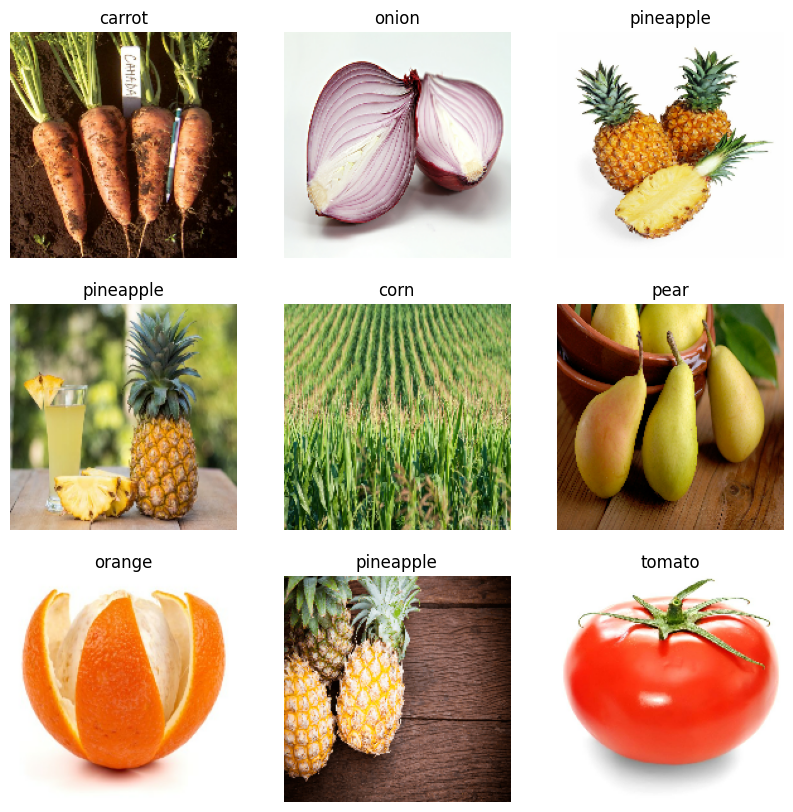

In [5]:
plt.figure(figsize=(10,10))
for image, labels in data_train.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(image[i].numpy().astype('uint8'))
        plt.title(data_cat[labels[i]])
        plt.axis('off')

In [6]:
model = Sequential([
    layers.Rescaling(1./255),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(128),
    layers.Dense(len(data_cat))
])

In [7]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

epochs_size = 25
history = model.fit(
    data_train,
    validation_data=data_val,
    epochs=epochs_size
)


Epoch 1/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 39s 361ms/step - accuracy: 0.1075 - loss: 3.3218 - val_accuracy: 0.3618 - val_loss: 2.3986
Epoch 2/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 36s 367ms/step - accuracy: 0.3066 - loss: 2.3836 - val_accuracy: 0.5755 - val_loss: 1.4943
Epoch 3/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 37s 377ms/step - accuracy: 0.4565 - loss: 1.8249 - val_accuracy: 0.7265 - val_loss: 1.0497
Epoch 4/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 37s 378ms/step - accuracy: 0.6170 - loss: 1.2897 - val_accuracy: 0.8405 - val_loss: 0.6071
Epoch 5/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 38s 381ms/step - accuracy: 0.7429 - loss: 0.8679 - val_accuracy: 0.8889 - val_loss: 0.4480
Epoch 6/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 36s 369ms/step - accuracy: 0.8510 - loss: 0.5123 - val_accuracy: 0.9003 - val_loss: 0.5547
Epoch 7/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 37s 378ms/step - accuracy: 0.8995 - loss: 0.3755 - val_accuracy: 0.9202 - val_loss: 0.4719
Epoch 8/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 35s 352ms/step - accuracy: 0.9213 - loss: 0.2942 - val_accu

In [8]:
# ✅ SAVE MODEL IN model/ FOLDER
model.save('model/image_classifier.keras')